In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy import cos
from math import log
from scipy.interpolate import interp1d
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
from scipy.optimize import fsolve
from sympy import symbols, Eq, solve

In [2]:
climate_api_data = pd.read_csv("../../data_files/data/climate_api_data_2016_2024.csv")

#### Initial testing, based on  empirical parameters approximated for Amazon data

In [4]:
#### Article parameters:

T_prime=25.6

# T1= 26.4 
# T2= 0.025
# omega1= 0.017
# phi1= -1.45

# R1= 250.083 
# R2= 0.565
# omega2= 0.02
# phi2=1.6

B_E=200
p_ME=0.9
p_ML=0.25
p_MP=0.75
tau_E=1
tau_P=1
c1=0.00554
c2=-0.06737
D1=36.5
b1=0.04
b2=0.09
A = 12.5
B = 15.0
C = -48.78
tau_H=10
DD=105
Tmin=14.5
gamma= 1/120
R_L = 32.67 #450 #968/30
N=8558
M=10000 

E_M0=5000 
I_H0=1000

if E_M0 is None:
        E_M0 = M / 100

S_H0 = N - I_H0
S_M0 = M - E_M0

In [5]:
def Temp():
    return climate_api_data['temp_med']

def Rain():
    return climate_api_data['precip_med']

In [6]:
def original_model(t, z, history, df, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
                   D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
                   N, M):
    
    S_H, I_H, R_H, S_M, E_M, I_M = z
    
    # Clamp to prevent negative values (numerical stability)
    S_H = max(S_H, 0)
    I_H = max(I_H, 0)
    R_H = max(R_H, 0)
    S_M = max(S_M, 0)
    E_M = max(E_M, 0)
    I_M = max(I_M, 0)
    
    # Get the closest integer day
    day_index = int(t)
    if day_index >= len(df):
        day_index = len(df) - 1
    
    T_curr = df.loc[day_index, 'temp_med']
    R_curr = df.loc[day_index, 'precip_med']
    
    # Temperature dependent quantities with bounds
    def tau_L(Temp):
        denom = c1 * Temp + c2
        if denom <= 0:
            return 100  # Large value if denominator non-positive
        return 1 / denom
    
    def p(Temp):
        denom = A * Temp**2 + B * Temp + C
        if denom >= 0:
            return 0.5  # Reasonable default if denominator non-negative
        return np.exp(-1 / denom)
    
    def p_LT(Temp):
        exponent = c1 * Temp + c2
        if exponent > 10:  # Prevent overflow
            return 0
        return np.exp(-exponent)
    
    def p_LR(Rain):
        if Rain < 0 or Rain > R_L:
            return 0
        return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)
    
    def p_ER(Rain):
        if Rain < 0 or Rain > R_L:
            return 0
        return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)
    
    def p_PR(Rain):
        if Rain < 0 or Rain > R_L:
            return 0
        return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)
    
    def tau_M(Temp):
        if Temp <= Tmin:
            return 100  # Large value if temperature too low
        return DD / (Temp - Tmin)
    
    tau_M_curr = tau_M(T_curr)
    
    def l_tau_M(tau_M, Temp):
        p_T = p(Temp)
        # Prevent numerical issues with power
        if p_T <= 0:
            return 0
        return p_T ** min(tau_M, 100)  # Cap tau_M for numerical stability
    
    l_curr = l_tau_M(tau_M_curr, T_curr)
    
    def mu(Temp):
        p_T = p(Temp)
        if p_T <= 0:
            return 0.5  # Reasonable maximum mortality
        mu_val = -np.log(p_T)
        return min(mu_val, 0.5)  # Cap mortality
    
    mu_curr = mu(T_curr)
    
    def a(Temp):
        a_val = (Temp - T_prime) / D1
        return max(0, a_val)  # Ensure non-negative biting rate
    
    a_curr = a(T_curr)
    
    def b(Rain, Temp):
        tau_L_curr = tau_L(Temp)
        numerator = B_E * p_ER(Rain) * p_LR(Rain) * p_LT(Temp) * p_PR(Rain)
        denominator = tau_E + tau_L_curr + tau_P
        if denominator <= 0:
            return 0
        return numerator / denominator
    
    b_curr = max(0, b(R_curr, T_curr))  # Ensure non-negative
    
    # Delayed states with bounds
    try:
        S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = history(t - tau_H)
        # Clamp delayed states
        S_H_delay = max(S_H_delay, 0)
        I_H_delay = max(I_H_delay, 0)
        S_M_delay = max(S_M_delay, 0)
        I_M_delay = max(I_M_delay, 0)
    except:
        # Use current if delay fails
        S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = S_H, I_H, 0, S_M, E_M, I_M
    
    try:
        tau_M_curr_safe = min(tau_M_curr, 100)  # Cap delay time
        S_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = history(t - tau_M_curr_safe)
        S_M_delay_M = max(S_M_delay_M, 0)
        I_H_delay_M = max(I_H_delay_M, 0)
    except:
        S_M_delay_M = S_M
        I_H_delay_M = I_H
    
    # Human equations with safeguards
    infection_rate_h = a_curr * b2 * (I_M / N) * S_H
    dShdt = -infection_rate_h
    
    infection_rate_h_delay = a_curr * b2 * (I_M_delay / N) * S_H_delay
    dIhdt = infection_rate_h_delay - gamma * I_H
    
    dRhdt = gamma * I_H
    
    # Mosquito equations with safeguards
    mosquito_birth = b_curr
    
    infection_rate_m = a_curr * b1 * (I_H / N) * S_M
    dSmdt = mosquito_birth - infection_rate_m - mu_curr * S_M
    
    infection_rate_m_delay = a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr
    dEmdt = infection_rate_m - infection_rate_m_delay - mu_curr * E_M
    
    dImdt = infection_rate_m_delay - mu_curr * I_M
    
    # Prevent negative derivatives from overshooting
    dShdt = max(dShdt, -S_H / 10)
    dIhdt = max(dIhdt, -I_H / 10)
    dRhdt = max(dRhdt, -R_H / 10)
    dSmdt = max(dSmdt, -S_M / 10)
    dEmdt = max(dEmdt, -E_M / 10)
    dImdt = max(dImdt, -I_M / 10)
    
    return [dShdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [7]:
initial_state = np.array([S_H0, I_H0, 0, S_M0, E_M0, 0])

In [8]:
def history(t):
    return initial_state

In [9]:
args = (history, climate_api_data, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
        D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
        N, M)

In [10]:
t_eval = np.linspace(0, 3289, 1000)

sol = solve_ivp(
    original_model,
    [0, 3289],
    initial_state,
    args=args,
    dense_output=True,
    t_eval=t_eval,
    method="BDF",  # Backward Differentiation Formula for stiff equations
    max_step=1.0,  # Limit maximum step size
    atol=1e-8,     # Tighter absolute tolerance
    rtol=1e-6      # Tighter relative tolerance
)

C:\Users\rapha\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
C:\Users\rapha\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
C:\Users\rapha\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
C:\Users\rapha\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [11]:
def history(t):
    if t <= 0:
        return initial_state
    return sol.sol(t)

In [12]:
times = sol.t
S_H, I_H, R_H, S_M, E_M, I_M = sol.y

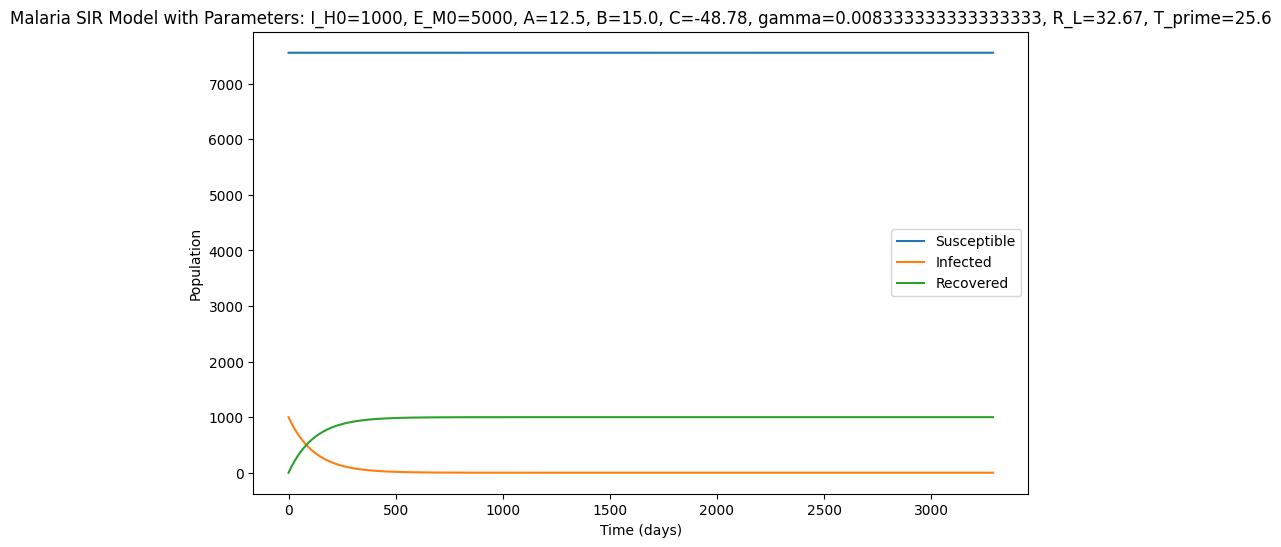

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_H, label='Susceptible')
plt.plot(times, I_H, label='Infected')
plt.plot(times, R_H, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(f'Malaria SIR Model with Parameters: I_H0={I_H0}, E_M0={E_M0}, A={round(A, 2)}, B={round(B, 2)}, C={round(C, 2)}, gamma={gamma}, R_L={R_L}, T_prime={round(T_prime, 2)}')

plt.legend()

plt.show()

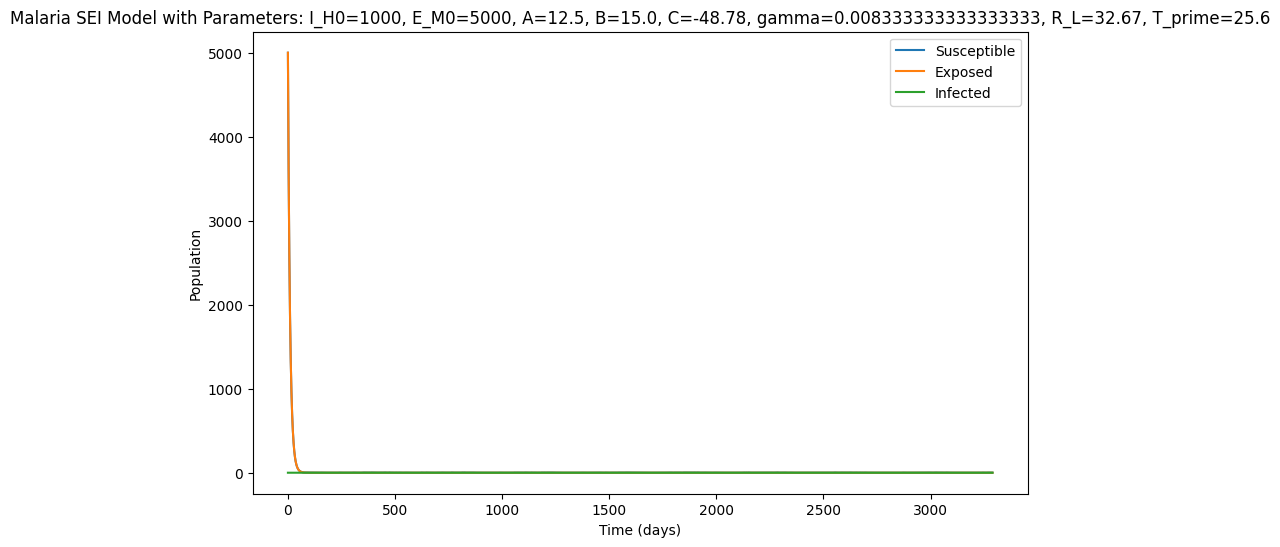

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_M, label='Susceptible')
plt.plot(times, E_M, label='Exposed')
plt.plot(times, I_M, label='Infected')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(f'Malaria SEI Model with Parameters: I_H0={I_H0}, E_M0={E_M0}, A={round(A, 2)}, B={round(B, 2)}, C={round(C, 2)}, gamma={gamma}, R_L={R_L}, T_prime={round(T_prime, 2)}')

plt.legend()

plt.show()

In [15]:
R_L = 450

args = (history, climate_api_data, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
        D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
        N, M)

t_eval = np.linspace(0, 3289, 1000)

sol = solve_ivp(
    original_model,
    [0, 3289],
    initial_state,
    args=args,
    dense_output=True,
    t_eval=t_eval,
    method="BDF",  # Backward Differentiation Formula for stiff equations
    max_step=1.0,  # Limit maximum step size
    atol=1e-8,     # Tighter absolute tolerance
    rtol=1e-6      # Tighter relative tolerance
)

In [16]:
times = sol.t
S_H, I_H, R_H, S_M, E_M, I_M = sol.y

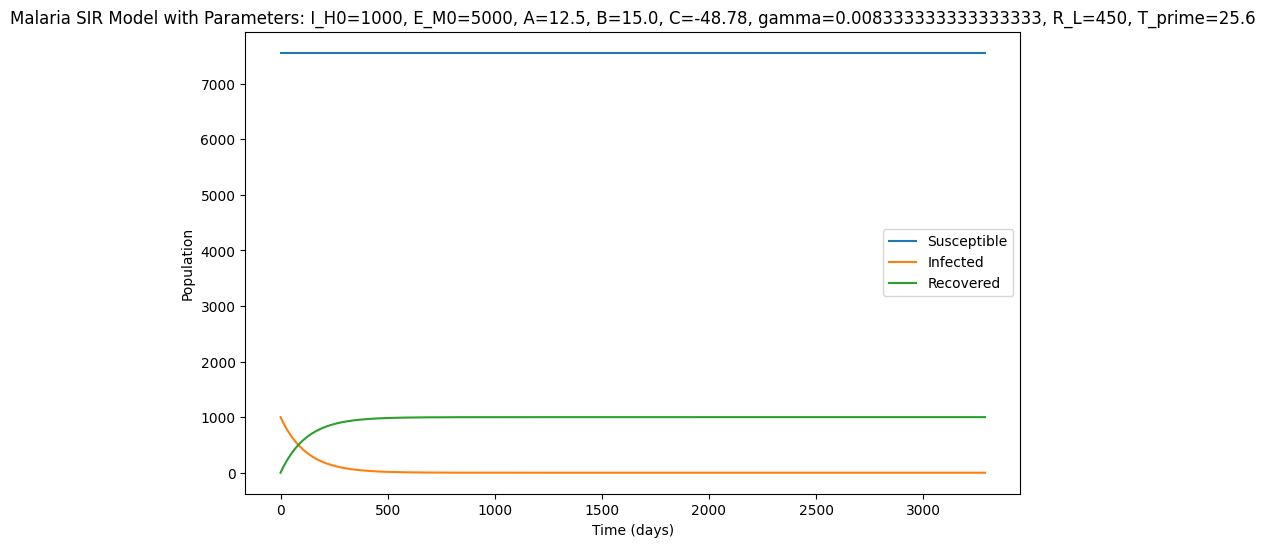

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_H, label='Susceptible')
plt.plot(times, I_H, label='Infected')
plt.plot(times, R_H, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(f'Malaria SIR Model with Parameters: I_H0={I_H0}, E_M0={E_M0}, A={round(A, 2)}, B={round(B, 2)}, C={round(C, 2)}, gamma={gamma}, R_L={R_L}, T_prime={round(T_prime, 2)}')

plt.legend()

plt.show()

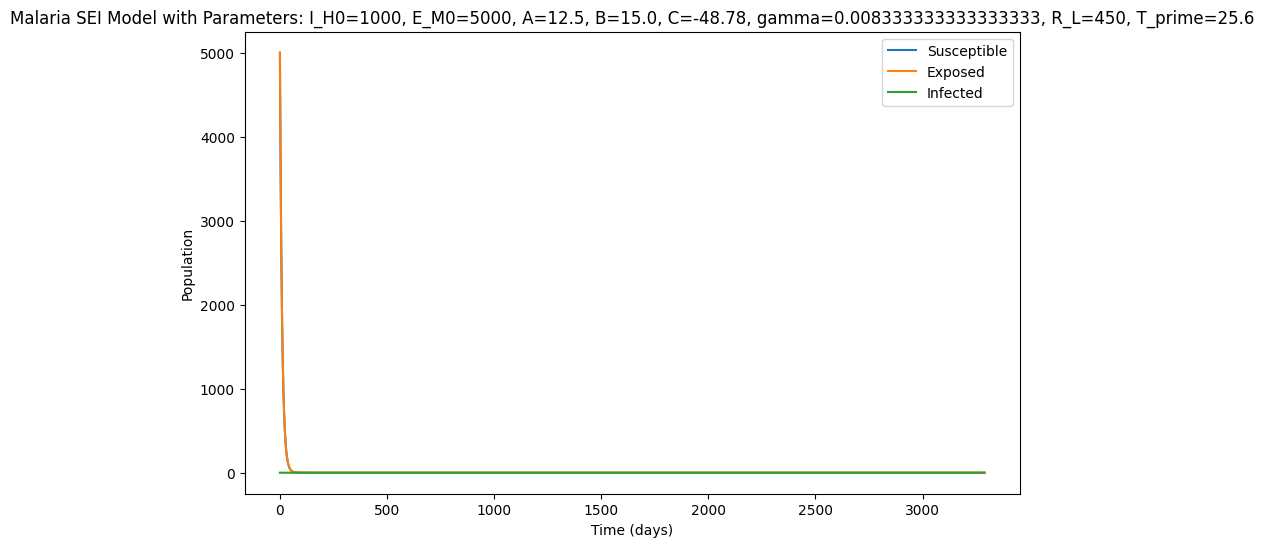

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_M, label='Susceptible')
plt.plot(times, E_M, label='Exposed')
plt.plot(times, I_M, label='Infected')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(f'Malaria SEI Model with Parameters: I_H0={I_H0}, E_M0={E_M0}, A={round(A, 2)}, B={round(B, 2)}, C={round(C, 2)}, gamma={gamma}, R_L={R_L}, T_prime={round(T_prime, 2)}')

plt.legend()

plt.show()